In [1]:
import sys
import os

# Add local data package to path (use raw string for Windows path to avoid escape issues)
sys.path.append(os.path.abspath(r'G:\Apply\Deep_Learning_Review\data'))

# Import the dataset wrapper that provides `get_flat_datasets`
from data.csv_data import HousePricesDatasetWrapper

# Instantiate the wrapper (handles loading/pars ing internally)
wrapper = HousePricesDatasetWrapper()

# Retrieve datasets: (train, validation, test)
train_data, valid_data, test_data = wrapper.get_flat_datasets()

G:\Apply\Deep_Learning_Review\.venv\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [2]:
#show train predictor

print(train_data[0].shape)

train_data[0][:2]

(505, 7)


array([[ 1.94509048,  1.39642758, -1.52275521, -0.64519476, -0.11676266,
        -0.13891486,  0.8225858 ],
       [ 1.93249288,  1.39642758, -1.49354416, -0.64519476, -0.11676266,
        -0.15597175,  0.80219322]])

In [3]:
#show the train target
print(train_data[1].shape)

train_data[1][:2]

(505, 1)


array([[22.],
       [22.]])

In [24]:
import math
import numpy as np

class Dense():
    def __init__(self, input_size, output_size, activation=True, seed=0):
        self.add_activation = activation
        self.hidden = None
        self.prev_hidden = None

        # Initialize the weights.  They'll be in the range -sqrt(k) to sqrt(k), where k = 1 / input_size
        np.random.seed(seed)
        k = math.sqrt(1 / input_size)
        self.weights = np.random.rand(input_size, output_size) * (2 * k) - k

        # Our bias will be initialized to 1
        self.bias = np.ones((1,output_size))

    def forward(self, x):
        # Copy the layer input for backprop
        self.prev_hidden = x.copy()
        # Multiply the input by the weights, then add the bias
        x = np.matmul(x, self.weights) + self.bias
        # Apply the activation function
        if self.add_activation:
            x = np.maximum(x, 0)
        # Copy the layer output for backprop
        self.hidden = x.copy()
        return x

    def backward(self, grad):
        # "Undo" the activation function if it was added
        if self.add_activation:
            grad = np.multiply(grad, np.heaviside(self.hidden, 0))

        # Calculate the parameter gradients
        w_grad = self.prev_hidden.T @ grad # This is not averaged across the batch, due to the way matrix multiplication sums
        b_grad = np.mean(grad, axis=0) # This is averaged across the batch
        param_grads = [w_grad, b_grad]

        # Calculate the next layer gradient
        grad = grad @ self.weights.T
        return param_grads, grad

    def update(self, w_grad, b_grad):
        # Update the weights given an update matrix
        self.weights += w_grad
        self.bias += b_grad

In [25]:
layers = [
    Dense(7, 25),
    Dense(25, 10),
    Dense(10, 1, activation=False)
]

In [26]:
def forward(x, layers):
    # Loop through each layer
    for layer in layers:
        # Run the forward pass
        x = layer.forward(x)
    return x

def backward(grad, layers):
    # Save the gradients for each layer
    layer_grads = []
    # Loop through each layer in reverse order (starting from the output layer)
    for layer in reversed(layers):
        # Get the parameter gradients and the next layer gradient
        param_grads, grad = layer.backward(grad)
        layer_grads.append(param_grads)
    return layer_grads

In [27]:
# Import the optimizer class
from optimizer import Optimizer

In [28]:
class SGD(Optimizer):
    def __init__(self, lr):
        # Store hyperparameters
        self.lr = lr
        super().__init__()

    def __call__(self, layer_grads, layers, batch_size, step):
        # Loop through the layer grads.  Reverse the layers to match the grads (from output backward to input).
        for layer_grad, layer in zip(layer_grads, reversed(layers)):
            w_grad, b_grad = layer_grad

            # Normalize the weight gradient by batch size
            w_grad /= batch_size

            # Calculate the update sizes
            w_update = -self.lr * w_grad
            b_update = -self.lr * b_grad

            # Actually do the update
            layer.update(w_update, b_update)

        # Save the first layer weights to generate a graph later.  This is not part of the SGD algorithm - we're doing it to graph the weight changes.
        self.save_vector(layers)

## Monitoring

In [36]:
import os
os.environ['WANDB_API_KEY'] = '4ba07b5be262c5fe880b9c7b0942037ed3e02be9'

In [37]:
%env WANDB_SILENT=True

import wandb
wandb.login()

env: WANDB_SILENT=True


False

In [38]:
import time

def training_run(epochs, batch_size, optimizer, train_data, valid_data, name=None):
    # Initialize a new W&B run, with the right parameters
    wandb.init(project="optimizers",
               name=name,
               config={"batch_size": batch_size,
                       "lr": optimizer.lr,
                       "epochs": epochs,
                       "optimizer": type(optimizer).__name__})

    # Setup the metrics we want to track with wandb.  You usually don't need to do this, but we want a custom axis for each metric.
    wandb.define_metric("batch_step") # This will ensure that results from runs with different batch sizes line up
    wandb.define_metric("epoch") # This will ensure that results from runs with different batch sizes line up
    wandb.define_metric("valid_loss", step_metric="epoch") # The step metric is the x-axis scale
    wandb.define_metric("train_loss", step_metric="epoch")
    wandb.define_metric("runtime", step_metric="epoch")
    wandb.define_metric("running_loss", step_metric="batch_step")

    # Setup the layers for the training run
    layers = [
        Dense(7, 25),
        Dense(25,10),
        Dense(10, 1, activation=False)
    ]

    # Split the training and valid data into x and y
    train_x, train_y = train_data
    valid_x, valid_y = valid_data

    for epoch in range(epochs):
        running_loss = 0
        start = time.time() # The start time of our run

        for i in range(0, len(train_x), batch_size):
            # Get the x and y batches
            x_batch = train_x[i:(i+batch_size)]
            y_batch = train_y[i:(i+batch_size)]
            # Make a prediction
            pred = forward(x_batch, layers)

            # Run the backward pass
            loss = pred - y_batch
            layer_grads = backward(loss, layers)

            # Run the optimizer
            step_count = (i + batch_size) // batch_size + epoch * len(train_x) // batch_size
            optimizer(layer_grads, layers, batch_size, step_count)

            # Update running loss
            running_loss += np.mean(loss ** 2)

            batch_idx = i + batch_size # Get the last index of the current batch
            batch_step = batch_idx + epoch * len(train_x)
            # Log running loss.  We multiply by batch size to offset the mean from earlier.
            wandb.log({"running_loss": running_loss / batch_idx * batch_size, "batch_step": batch_step})

        # Calculate and log validation loss
        valid_preds = forward(valid_x, layers)
        valid_loss = np.mean((valid_preds - valid_y) ** 2)
        train_loss = running_loss / len(train_x) * batch_size
        wandb.log({
            "valid_loss": valid_loss,
            "epoch": epoch,
            "train_loss": train_loss,
            "runtime": time.time() - start
        })

    # Mark the run as complete
    wandb.finish()

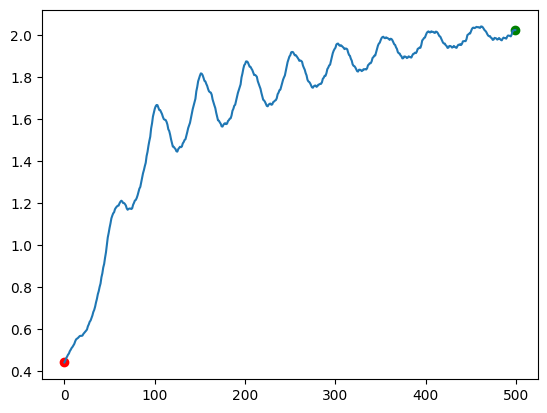

In [42]:
epochs = 10
batch_size = 4
lr = 1e-4

# Run our training loop
sgd = SGD(lr=lr)
training_run(epochs, batch_size, sgd, train_data, valid_data, name="sgd_small")

# Plot the path of the weights over time.
sgd.plot_path()

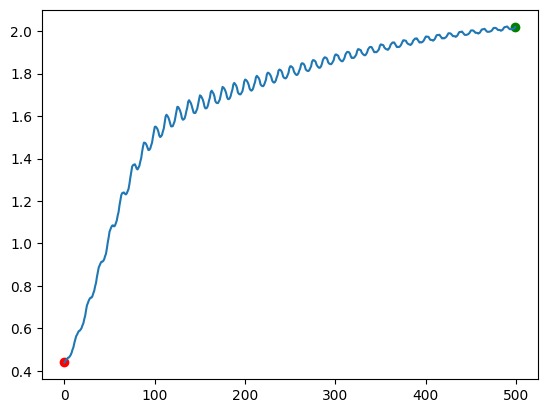

In [41]:
# Setup our parameters
epochs = 40 # higher number of epochs so total steps are equal for comparison purposes
batch_size = 16
lr = 1e-4

# Run our training loop
sgd = SGD(lr=lr)
training_run(epochs, batch_size, sgd, train_data, valid_data, name="sgd_large")
sgd.plot_path()

We can draw a few conclusions from this graph and the graph of our average weights:

1. The higher batch size descends more slowly than a lower batch size
2. The higher batch size converges to a higher training and validation loss
3. The higher batch size runs each epoch much faster
4. A higher batch size has more stable weight updates - the singular value of the weight matrix doesn't get pulled back and forth as much (in the graph)


Batch size can make a big impact on the final accuracy of your model. In general, a higher batch size is a form of regularization (which we'll talk about in depth in a later lesson). Regularization increases training loss, but decreases validation loss. This happens because you're averaging over multiple training examples in the batch, and making it harder to overfit to specific examples. It may seem counterintuitive, but our goal in training neural networks isn't to get the lowest training loss possible. It's instead to get the lowest validation loss possible. This is because we want the model to work well on new data that we feed into it after it's been trained. Regularization helps the model generalize well to new data.

Higher batch sizes can run much faster than lower batch sizes. This is because we're just adding rows to existing matrices. In practice, if the batch size is too high, then validation loss starts to suffer. So you need to find the batch size that runs quickly and minimizes validation loss. This is different for each dataset, so it can take some experimentation.

### Momentum

In [43]:
# Initialize a list of random stock prices between 2 and 10
prices = np.random.randint(2,10,10)
prices

array([8, 9, 9, 8, 2, 3, 7, 3, 7, 2], dtype=int32)

In [44]:
exp_avg = []
ema = prices[0] # Store the moving average.  Initialize it to the first value.
decay = .5 # How fast the values decay.  The higher this is, the more we care about past values

# Calculate the exponential average
for i in range(prices.shape[0]):
    ema = decay * ema  + (1-decay) * prices[i]
    exp_avg.append(ema)
np.vstack((prices, exp_avg))

array([[8.    , 9.    , 9.    , 8.    , 2.    , 3.    , 7.    , 3.    ,
        7.    , 2.    ],
       [8.    , 8.5   , 8.75  , 8.375 , 5.1875, 4.0938, 5.5469, 4.2734,
        5.6367, 3.8184]])